# Train YOLO Model on RealWaste Dataset

## Directory Tree

- datasets/
    - RealWaste/
        - Cardboard/
        - Food Organics/
        - Glass/
        - Metal/
        - Miscellaneous Trash/
        - Paper/
        - Plastic/
        - Textile Trash/
        - Vegetation/

In [2]:
import os
import shutil
import random
from pathlib import Path
from ultralytics import YOLO

dataset_path = Path('datasets/RealWaste')
processed_path = Path('datasets/processed')
train_path = processed_path / 'train'
val_path = processed_path / 'val'

if processed_path.exists():
    shutil.rmtree(processed_path)

train_path.mkdir(parents=True, exist_ok=True)
val_path.mkdir(parents=True, exist_ok=True)

classes = [d.name for d in dataset_path.iterdir() if d.is_dir()]
print(f"Found classes: {classes}")

# Split ratio
split_ratio = 0.8

for class_name in classes:
    class_dir = dataset_path / class_name
    images = list(class_dir.glob('*.jpg'))
    random.shuffle(images)
    
    split_idx = int(len(images) * split_ratio)
    train_images = images[:split_idx]
    val_images = images[split_idx:]
    
    # Create class directories in train and val
    (train_path / class_name).mkdir(exist_ok=True)
    (val_path / class_name).mkdir(exist_ok=True)
    
    for img in train_images:
        shutil.copy(img, train_path / class_name / img.name)
        
    for img in val_images:
        shutil.copy(img, val_path / class_name / img.name)
        
    print(f"Processed {class_name}: {len(train_images)} train, {len(val_images)} val")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/home/kris/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Found classes: ['Cardboard', 'Food Organics', 'Glass', 'Metal', 'Miscellaneous Trash', 'Paper', 'Plastic', 'Textile Trash', 'Vegetation']
Processed Cardboard: 368 train, 93 val
Processed Food Organics: 328 train, 83 val
Processed Glass: 336 train, 84 val
Processed Metal: 632 train, 158 val
Processed Miscellaneous Trash: 396 train, 99 val
Processed Paper: 400 train, 100 val
Processed Plastic: 736 train, 185 val
Processed Textile Trash: 254 train, 64 val
Processed Vegetation: 348 train, 88 val


In [10]:

import torch

print(f"PyTorch Version: {torch.__version__}")
# You want to see something like: 2.5.1+cu121
# If you see just '2.5.1', it is still the CPU version.

print(f"XPU Available: {torch.xpu.is_available()}")

if torch.xpu.is_available():
    print(f"Current GPU: {torch.xpu.get_device_name(0)}")

device = torch.device('xpu' if torch.xpu.is_available() else 'cpu') 


PyTorch Version: 2.9.1+xpu
XPU Available: True
Current GPU: Intel(R) Arc(TM) Graphics


In [ ]:
# Ultralytics has hardcoded CUDA calls that break on XPU
# Monkey-patch functions to work with XPU
import ultralytics.engine.trainer as trainer_module
import ultralytics.engine.validator as validator_module
import ultralytics.utils.torch_utils as torch_utils_module
import gc

def _get_memory_xpu(self, fraction=False):
    """XPU-compatible memory getter."""
    memory = torch.xpu.memory_reserved() if hasattr(torch.xpu, 'memory_reserved') else 0
    if fraction:
        return 0.1  # Return low fraction to skip memory clearing
    return memory / 2**30

def _clear_memory_xpu(self, threshold=0.5):
    """XPU-compatible memory clearing."""
    gc.collect()
    if hasattr(torch.xpu, 'empty_cache'):
        torch.xpu.empty_cache()

# Patch the select_device function to handle XPU
_original_select_device = torch_utils_module.select_device

def select_device_xpu(device="", newline=False, verbose=True):
    """XPU-aware device selector."""
    device_str = str(device).strip().lower()
    if device_str == "xpu" or (hasattr(device, 'type') and device.type == 'xpu'):
        if torch.xpu.is_available():
            return torch.device('xpu')
    return _original_select_device(device, newline, verbose)

# Apply all patches
trainer_module.BaseTrainer._get_memory = _get_memory_xpu
trainer_module.BaseTrainer._clear_memory = _clear_memory_xpu

# Patch select_device everywhere it's imported
torch_utils_module.select_device = select_device_xpu
trainer_module.select_device = select_device_xpu
validator_module.select_device = select_device_xpu

# Also patch in ultralytics.utils (where it might be imported from)
import ultralytics.utils
ultralytics.utils.torch_utils.select_device = select_device_xpu

In [ ]:
model = YOLO('yolov8n-cls.pt').to('xpu')  # load a pretrained model (recommended for training)

results = model.train(data=str(processed_path.absolute()), epochs=4, imgsz=224, amp=False, device='xpu')

engine/trainer: agnostic_nms=False, amp=False, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/kris/Documents/projects/ai-plastic-spotter/datasets/processed, degrees=0.0, deterministic=True, device=xpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=4, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pretrained=True, profile=False, proj

Top prediction: Plastic (0.451)
  Plastic: 0.451
  Paper: 0.234
  Miscellaneous Trash: 0.140
  Cardboard: 0.088
  Textile Trash: 0.043


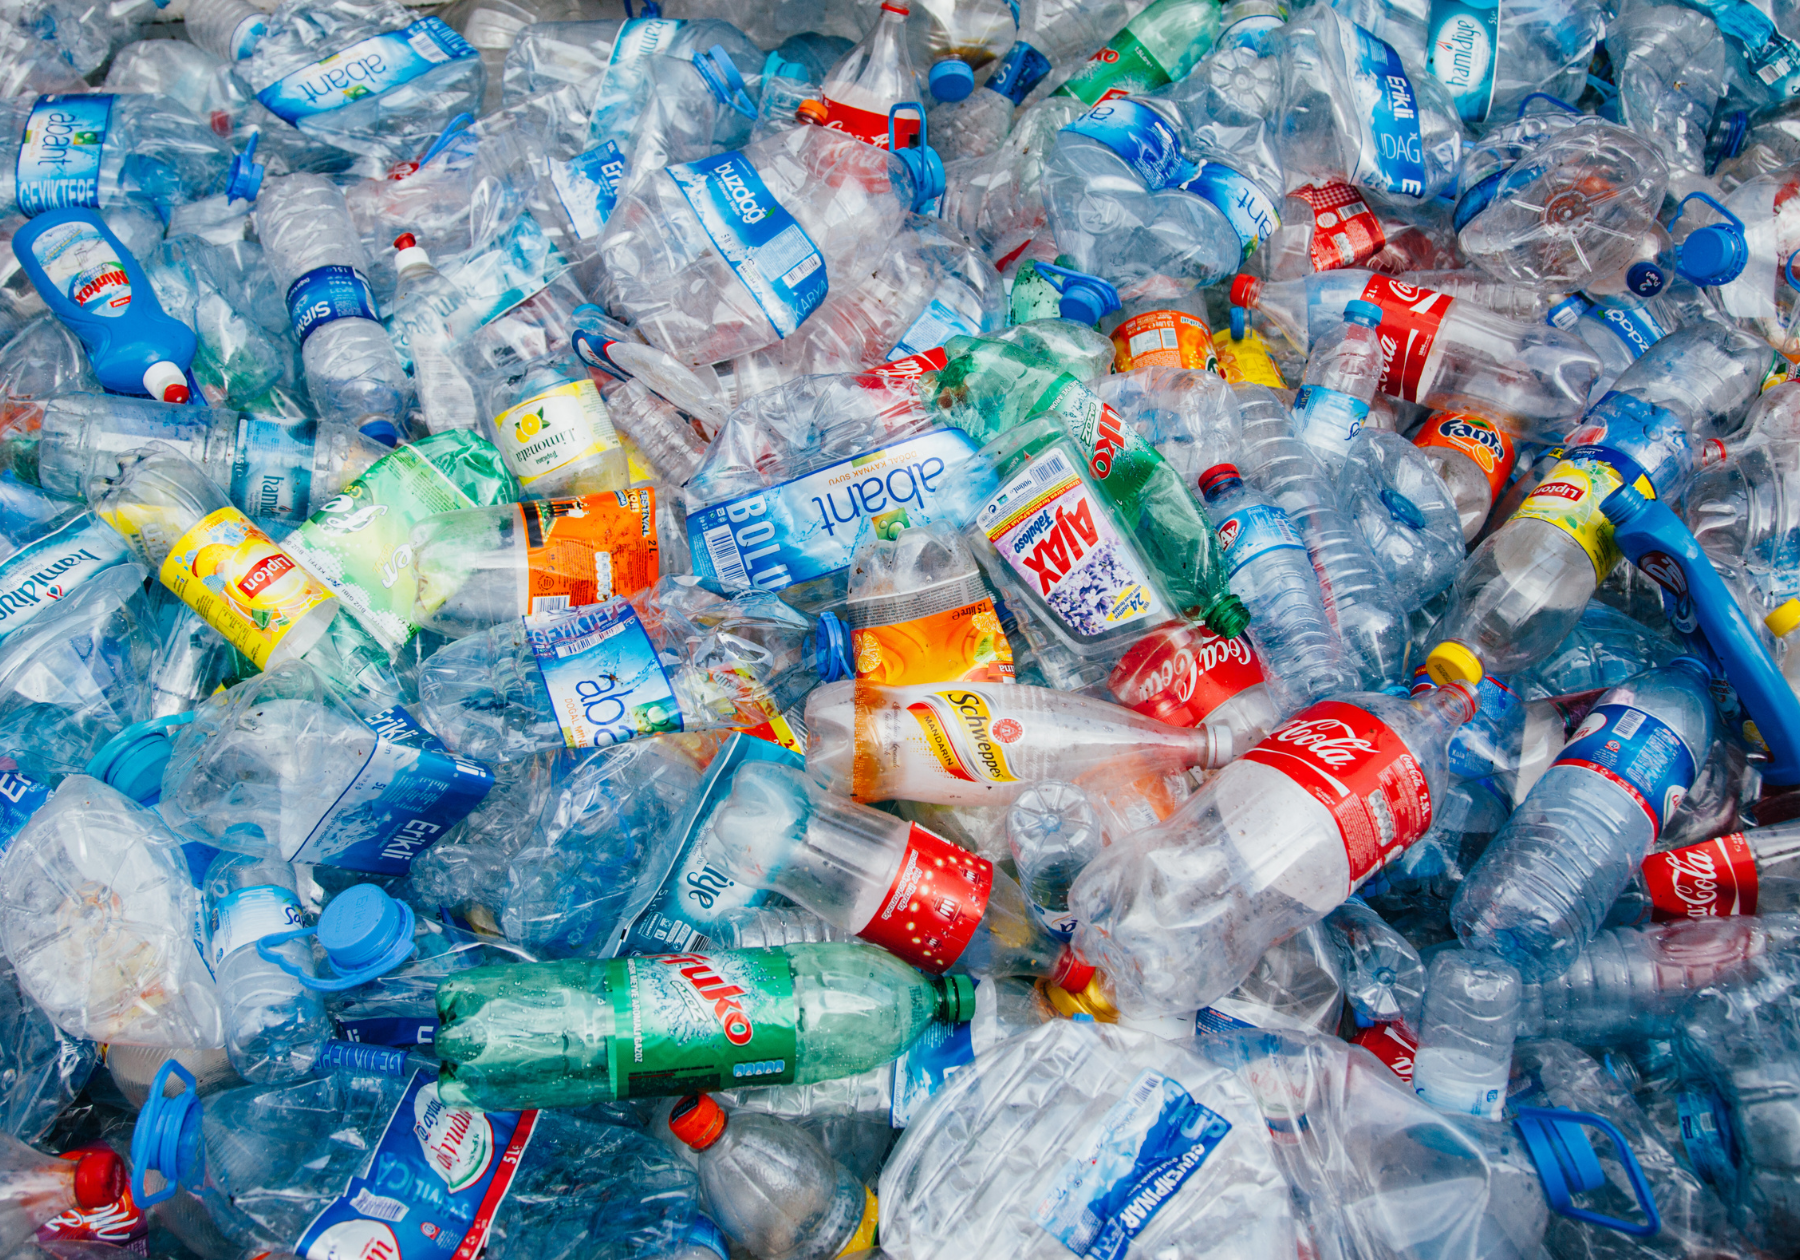

In [16]:
best_weights = Path('runs/classify/train/weights/best.pt')
if not best_weights.exists():
    raise FileNotFoundError(f"{best_weights} not found; rerun training or adjust the path.")

test_image = Path('plastic-bottle-waste.png')
if not test_image.exists():
    raise FileNotFoundError(f"{test_image} not found; place the sample image alongside the notebook.")

infer_model = YOLO(str(best_weights)).to('xpu')
results = infer_model.predict(source=str(test_image), imgsz=640, conf=0.3, verbose=False)
result = results[0]

if hasattr(result, 'probs') and result.probs is not None:
    probs = result.probs
    top_idx = int(probs.top1)
    top_label = result.names[top_idx]
    print(f"Top prediction: {top_label} ({float(probs.top1conf):.3f})")
    # Print the top few confidences exposed by the Probs helper
    for idx, conf in zip(probs.top5, probs.top5conf):
        label = result.names[idx]
        print(f"  {label}: {float(conf):.3f}")
else:
    print('Unexpected output format; check that the model is a classification checkpoint.')

# Display the test image that was classified
from PIL import Image
from IPython.display import display
display(Image.open(test_image))